# Responsverloop model 4a

Deze notebook toont het responsverloop voor model 4a. 

## Invoer

De volgende invoer wordt gebruikt:

In [1]:
from wsbd import model4a as m4a
import numpy as np
from probabilistic_library import UncertaintyProject, DistributionType, UncertaintyMethod

# Onzekere eigenschappen
# gebruik: [verwachtingswaarde, variatiecoëfficiënt]
kD = [2500.0, 0.5] # m2/d
D = [50.0, 0.1] # m
c1 = [30.0, 0.15] # dagen
c3 = [60.0, 0.15] # dagen

# geometrie is vast
L1 = 200.0 # m
L2 = 25.0 # m
L3 = 3500.0 # m

# Definieer model voor verwachtingswaarden

In [2]:
# definieer model met x = 0 ter plaatse van de binnenteen
model = m4a.Model4a(kD = kD[0], D = D[0], c1 = c1[0], c3 = c3[0], L1 = L1, L3 = L3, x_but = -1.0*L2, x_bit = 0.0)



In [3]:
# create een array met x-coördinaten van de binnenteen tot de buitenteen
x = np.linspace(-1.0*(L1+L2), L3, 100)
respons = [model.respons(loc)[0] for loc in x]

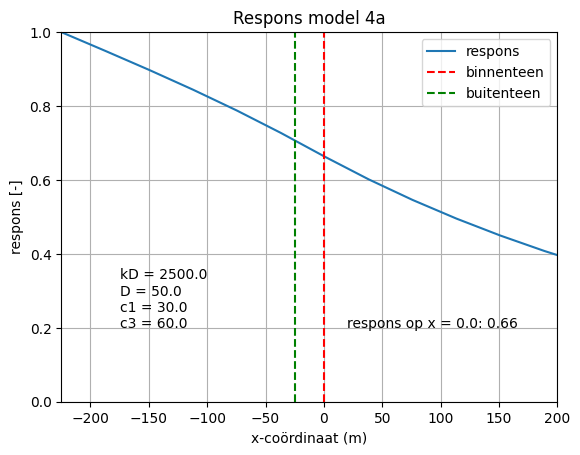

In [4]:
# define function om de respons weer te geven in een grafiek
def plot_respons(x, respons, xlim_right = L3):
    import matplotlib.pyplot as plt
    plt.plot(x, respons, label='respons')
    plt.xlabel('x-coördinaat (m)')
    plt.ylabel('respons [-]')
    plt.ylim(0, 1.0)
    # verticaal lijntje bij de binnenteen
    plt.axvline(x=0.0, color='r', linestyle='--', label='binnenteen')
    # verticaal lijntje bij de buitenteen
    plt.axvline(x=-1.0*L2, color='g', linestyle='--', label='buitenteen')
    plt.xlim(-1.0*(L1+L2), xlim_right)
    # add text with the values of the parameters
    #plt.text(-1.0*(L1+L2)+50, 0.2, f'kD = {kD[0]:.1f} ± {kD[0]*kD[1]:.1f}\nD = {D[0]:.1f} ± {D[0]*D[1]:.1f}\nc1 = {c1[0]:.1f} ± {c1[0]*c1[1]:.1f}\nc3 = {c3[0]:.1f} ± {c3[0]*c3[1]:.1f}', fontsize=10)
    plt.text(-1.0*(L1+L2)+50, 0.2, f'kD = {kD[0]:.1f} \nD = {D[0]:.1f} \nc1 = {c1[0]:.1f} \nc3 = {c3[0]:.1f} ', fontsize=10)
    plt.text(20.0,0.2, f'respons op x = 0.0: {model.respons(0)[0]:.2f}', fontsize=10)
    plt.legend()
    plt.title('Respons model 4a')
    plt.grid()
    plt.show()

plot_respons(x, respons, xlim_right = 200)

## Onzekerheidsanalyse

De geohydrologische eigenschappen zijn onzeker. Wat is dan het effect van deze onzekerheden op de respons in de binnenteen?
We gebruiken hiervoor de `UncertaintyProject` uit de probabilistic library: [zie](https://deltares.github.io/ProbabilisticLibrary/_examples/uncertainty_analysis.html).

In [5]:
# definieer een model voor de probabilistische analyse

def model4a_probabilistisch(kD, D, c1, c3, L1, L2, L3):
    model = m4a.Model4a(kD = kD, D = D, c1 = c1, c3 = c3, L1 = L1, L3 = L3, x_but = -1.0*L2, x_bit = 0.0)
    respons_bit = model.respons(0)[0]
    return respons_bit

# definieer een project voor de probabilistische analyse
project = UncertaintyProject()
project.model = model4a_probabilistisch
project.model.print()


Model model4a_probabilistisch:
Input parameters:
  kD
  D
  c1
  c3
  L1
  L2
  L3
Output parameters:
  respons_bit


We definiëren de variabelen:

In [6]:
project.variables['kD'].distribution = DistributionType.log_normal
project.variables['kD'].mean = kD[0]
project.variables['kD'].variation = kD[1]
project.variables['D'].distribution = DistributionType.log_normal
project.variables['D'].mean = D[0]
project.variables['D'].variation = D[1]
project.variables['c1'].distribution = DistributionType.log_normal
project.variables['c1'].mean = c1[0]
project.variables['c1'].variation = c1[1]
project.variables['c3'].distribution = DistributionType.log_normal
project.variables['c3'].mean = c3[0]
project.variables['c3'].variation = c3[1]

project.variables['L1'].distribution = DistributionType.deterministic
project.variables['L1'].mean = L1
project.variables['L2'].distribution = DistributionType.deterministic
project.variables['L2'].mean = L2
project.variables['L3'].distribution = DistributionType.deterministic
project.variables['L3'].mean = L3


# Monte Carlo analyse

ok
None
Variable respons_bit:
  distribution = histogram
Definition:
  amount[0.5264, 0.5297] = 3
  amount[0.5297, 0.533] = 2
  amount[0.533, 0.5364] = 3
  amount[0.5364, 0.5397] = 2
  amount[0.5397, 0.543] = 2
  amount[0.543, 0.5463] = 8
  amount[0.5463, 0.5496] = 4
  amount[0.5496, 0.5529] = 9
  amount[0.5529, 0.5563] = 9
  amount[0.5563, 0.5596] = 15
  amount[0.5596, 0.5629] = 17
  amount[0.5629, 0.5662] = 23
  amount[0.5662, 0.5695] = 26
  amount[0.5695, 0.5728] = 31
  amount[0.5728, 0.5762] = 32
  amount[0.5762, 0.5795] = 44
  amount[0.5795, 0.5828] = 54
  amount[0.5828, 0.5861] = 62
  amount[0.5861, 0.5894] = 78
  amount[0.5894, 0.5927] = 65
  amount[0.5927, 0.5961] = 95
  amount[0.5961, 0.5994] = 104
  amount[0.5994, 0.6027] = 91
  amount[0.6027, 0.606] = 126
  amount[0.606, 0.6093] = 120
  amount[0.6093, 0.6126] = 137
  amount[0.6126, 0.616] = 167
  amount[0.616, 0.6193] = 154
  amount[0.6193, 0.6226] = 182
  amount[0.6226, 0.6259] = 175
  amount[0.6259, 0.6292] = 214
  amount[

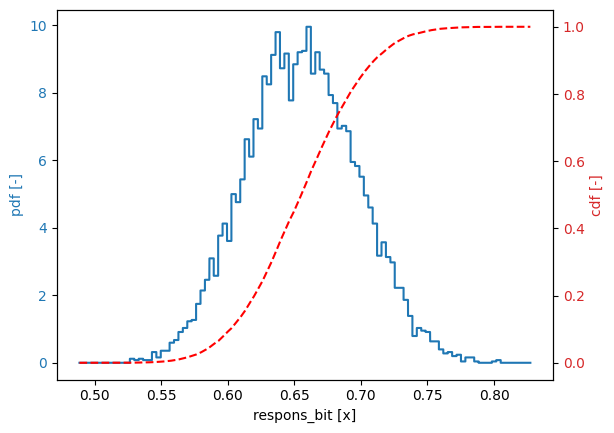

In [7]:
project.settings.uncertainty_method = UncertaintyMethod.crude_monte_carlo
project.settings.minimum_samples = 1000
project.settings.maximum_samples = 10000
project.settings.save_realizations = True

# print(project.settings.validate())

# Voer de onzekerheidsanalyse uit
project.run()

# sla het resultaat op in een variabele
onzekerheid_respons_bit = project.stochast
onzekerheid_respons_bit.print()
onzekerheid_respons_bit.plot()